In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

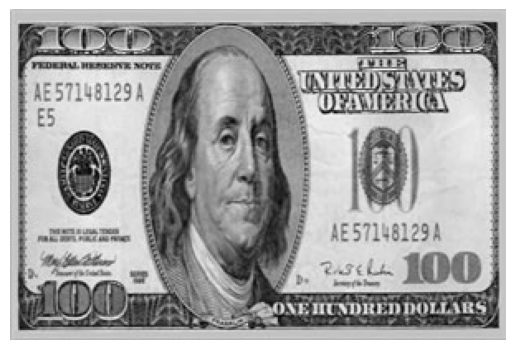

In [2]:
# 1. Contrast Stretching
img = cv.imread("/Users/ved/dip/images/img1-1.bmp", 0)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [3]:
L = 255
r1 = 80
r2 = 150
s1 = 30
s2 = 150

a = s1/r1
b = (s2 - s1)/(r2 - r1)
c = (L - s2)/(L-r2)

contrast_image = np.zeros_like(img, dtype=np.float32)
rows, cols = img.shape

In [4]:
for row in range(rows):
    for col in range(cols):
        if img[row][col] <=r1 :
            contrast_image[row][col] = img[row][col]*a
        elif img[row][col] > r1 and img[row][col] <= r2:
            contrast_image[row][col] = (img[row][col] - r1)*b + s1
        elif img[row][col] > r2 :
            contrast_image[row][col] = (img[row][col] - r2)*c + s2

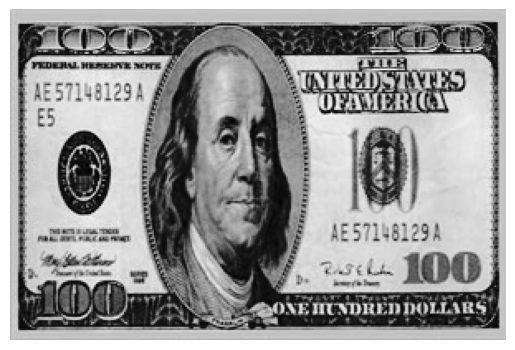

In [5]:
contrast_image = np.clip(contrast_image, 0, 255).astype(np.uint8)
plt.imshow(contrast_image, cmap="gray")
plt.axis("off")
plt.show()

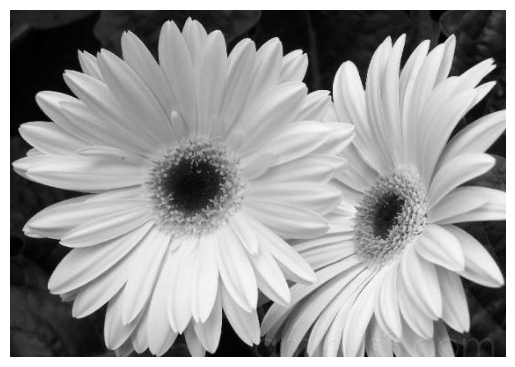

In [6]:
# 2. Gray Level Slicing
img = cv.imread("/Users/ved/dip/images/img1-2.bmp", 0)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

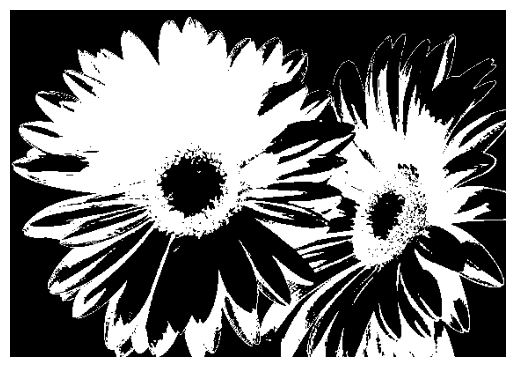

In [7]:
# 2.0.1 A. Without Background
upper = 200
lower = 100
threshold = 255
slicing_image = np.zeros_like(img)
rows, cols = img.shape
for row in range(rows):
    for col in range(cols):
        if img[row][col] >= lower and img[row][col] <= upper:
            slicing_image[row][col] = threshold
        else :
            slicing_image[row][col] = 0

plt.imshow(slicing_image, cmap='gray')
plt.axis("off")
plt.show()

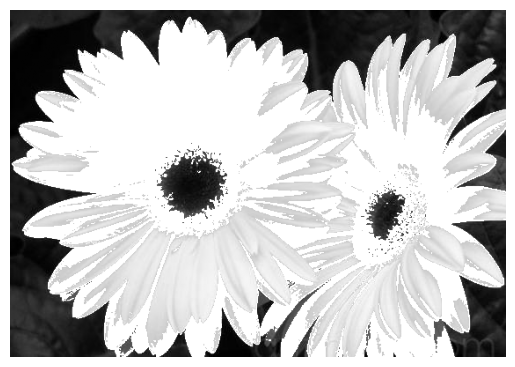

In [8]:
# 2.0.2 B. With Background
upper = 200
lower = 100
threshold = 255
slicing_image1 = np.zeros_like(img)
rows, cols = img.shape
for row in range(rows):
    for col in range(cols):
        if img[row][col] >= lower and img[row][col] <= upper:
            slicing_image1[row][col] = threshold
        else :
            slicing_image1[row][col] = img[row][col]

plt.imshow(slicing_image1, cmap='gray')
plt.axis("off")
plt.show()

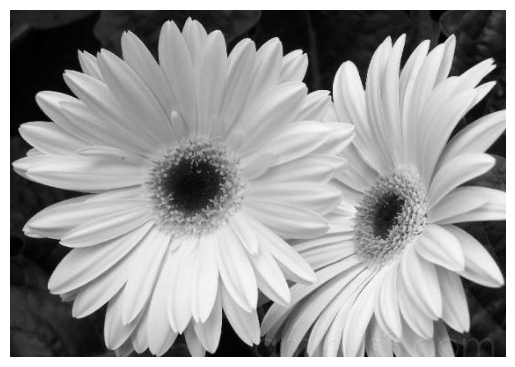

In [9]:
# 3. Bit Plane Slicing
img = cv.imread("/Users/ved/dip/images/img1-2.bmp", 0)
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

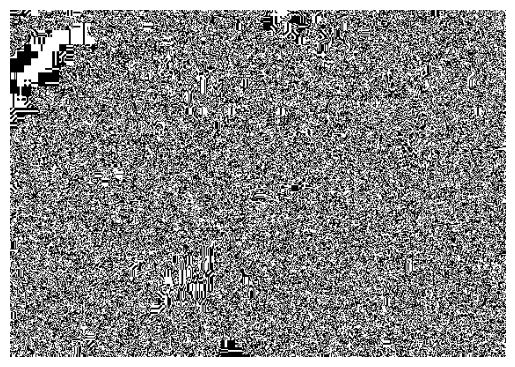

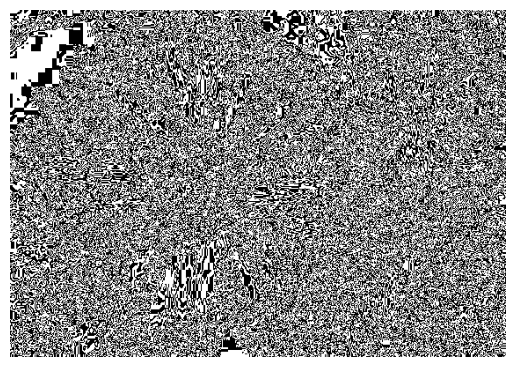

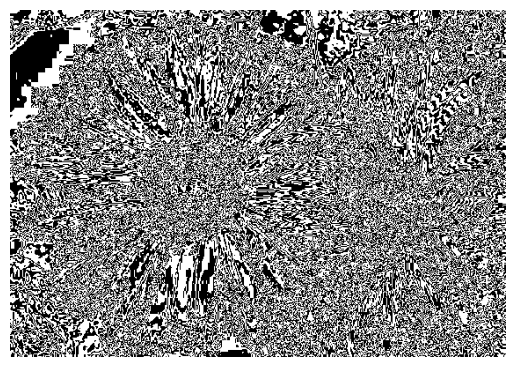

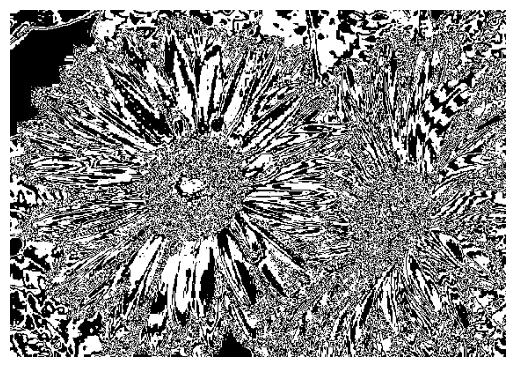

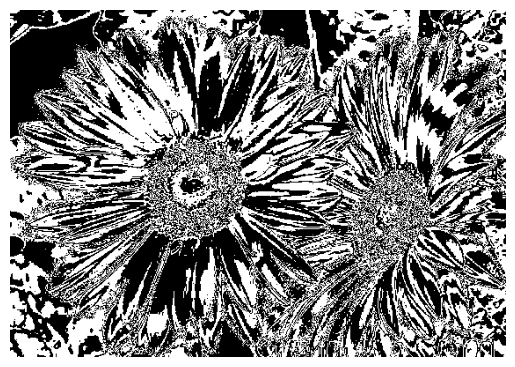

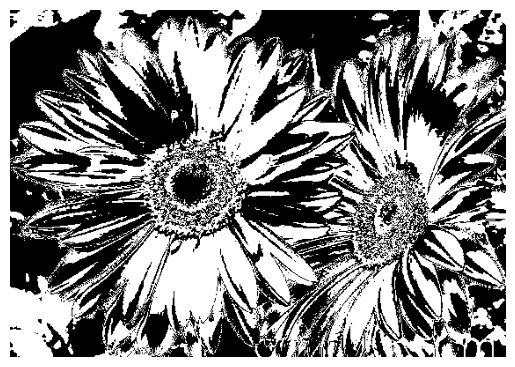

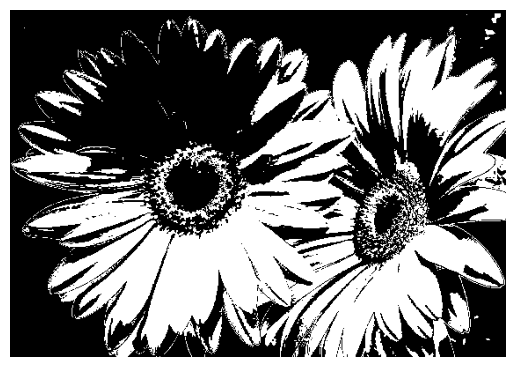

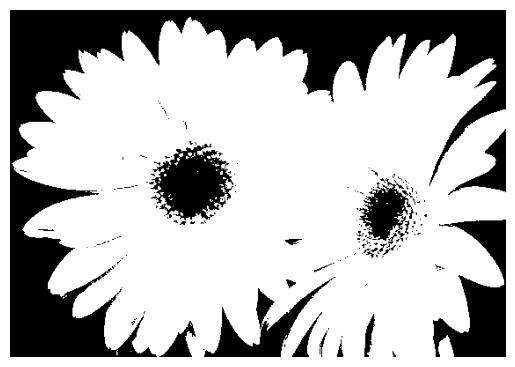

In [10]:
planes = []
for i in range(8):
    plane = (img>>i) & 1
    planes.append(plane*255)

for i in range(8):
    plt.imshow(planes[i], cmap="gray")
    plt.axis("off")
    plt.show()